In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import ast
import pickle

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_g = "/content/drive/MyDrive/AAGrafos/Proyecto/construccion_grafo/grafo_base_G_sin_filtro_2.pkl"


with open(path_g, 'rb') as f:
    G = pickle.load(f)

In [ ]:
len(G.edges)

7318

In [ ]:
path_paradas = "/content/drive/MyDrive/AAGrafos/Proyecto/v_uptu_paradas.zip"
gdf_paradas = gpd.read_file(path_paradas, encoding='utf-8')
gdf_paradas.columns = gdf_paradas.columns.str.strip()
gdf_paradas = gdf_paradas.drop(columns=['COD_VARIAN', 'DESC_LINEA', 'ORDINAL', 'CALLE', 'ESQUINA', 'COD_CALLE1', 'COD_CALLE2'])


gdf_paradas[["COD_UBIC_P"]] = gdf_paradas[["COD_UBIC_P"]].astype('Int64')
gdf_paradas = gdf_paradas.drop_duplicates(subset=['COD_UBIC_P']).set_index('COD_UBIC_P')

display(gdf_paradas.head())

,X,Y,geometry
COD_UBIC_P,,,
546,577981.398033,6.140775e+06,POINT (577981.398 6140774.574)
547,577902.796993,6.140892e+06,POINT (577902.797 6140892.492)
548,577926.505890,6.140845e+06,POINT (577926.506 6140844.778)
549,577776.314160,6.141078e+06,POINT (577776.314 6141077.736)
550,577751.540270,6.141104e+06,POINT (577751.54 6141103.685)


## Otros dias

In [ ]:
def verificar_datetime(df_viajes):
  # Ensure 'fecha_evento' is a datetime object
  df_viajes['fecha_evento'] = pd.to_datetime(df_viajes['fecha_evento'])

  # Extract the hour from 'fecha_evento'
  df_viajes['hora'] = df_viajes['fecha_evento'].dt.hour

  # Sort by id_viaje and fecha_evento to ensure correct sequence for time difference calculation
  df_viajes = df_viajes.sort_values(by=['id_viaje', 'fecha_evento'])

  # Calculate the time difference (travel time) for each segment of a trip
  # The 'codigo_parada_origen' in one row is the origin, and in the next row, it would be the destination
  df_viajes['next_parada'] = df_viajes.groupby('id_viaje')['codigo_parada_origen'].shift(-1)
  df_viajes['time_to_next_parada'] = df_viajes.groupby('id_viaje')['fecha_evento'].diff().shift(-1)

  # Drop rows where 'next_parada' or 'time_to_next_parada' are NaN (these are the last stops of each trip)
  df_viajes.dropna(subset=['next_parada', 'time_to_next_parada'], inplace=True)

  # Convert time_to_next_parada to seconds for easier aggregation
  df_viajes['time_to_next_parada_seconds'] = df_viajes['time_to_next_parada'].dt.total_seconds()

  display(df_viajes.head())

  return df_viajes

In [ ]:
def calcular_tiempo(df_viajes):
  # Aggregate travel times by hour, origin, and destination
  df_hourly_travel_times = df_viajes.groupby(['hora', 'codigo_parada_origen', 'next_parada'])['time_to_next_parada_seconds'].mean().reset_index()

  # Convert 'next_parada' to int for consistency with node IDs
  df_hourly_travel_times['next_parada'] = df_hourly_travel_times['next_parada'].astype(int)

  display(df_hourly_travel_times.head())
  df_hourly_travel_times.info()

  return df_hourly_travel_times

In [ ]:
# Load the accident dataset
path_accidents = "/content/drive/MyDrive/AAGrafos/Proyecto/dataset_accidentes_hora.csv"
df_accidents = pd.read_csv(path_accidents)
display(df_accidents.head())
df_accidents.info()

# Ensure 'fecha_evento' is a datetime object
df_accidents['fecha_evento'] = pd.to_datetime(df_accidents['fecha_hora_exacta'])

# Filter for September data (assuming the year is 2022 as in other datasets)
df_accidents_september = df_accidents[(df_accidents['fecha_evento'].dt.month == 9) & (df_accidents['fecha_evento'].dt.year == 2022)]

# Extract the hour from 'fecha_evento'
df_accidents_september['hora'] = df_accidents_september['fecha_evento'].dt.hour

display(df_accidents_september.head())
df_accidents_september.info()
# Display the first few rows and information about the DataFrame
def accidentes_del_dia(day_to_process):


  df_accidents_september_day = df_accidents_september[df_accidents_september['fecha_evento'].dt.day == day_to_process]

  display(df_accidents_september_day.head())
  df_accidents_september_day.info()

  return df_accidents_september_day

,Unnamed: 0,cod_ubic_p,fecha_hora_exacta,cantidad_accidentes
0,0,550,2022-09-10 15:00:00,1
1,1,551,2022-01-20 12:00:00,1
2,2,551,2022-02-18 16:00:00,1
3,3,551,2022-06-02 15:00:00,1
4,4,551,2022-06-09 11:00:00,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4433 entries, 0 to 4432
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           4433 non-null   int64 
 1   cod_ubic_p           4433 non-null   int64 
 2   fecha_hora_exacta    4433 non-null   object
 3   cantidad_accidentes  4433 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 138.7+ KB


/tmp/ipykernel_217/1983297880.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_accidents_september['hora'] = df_accidents_september['fecha_evento'].dt.hour


,Unnamed: 0,cod_ubic_p,fecha_hora_exacta,cantidad_accidentes,fecha_evento,hora
0,0,550,2022-09-10 15:00:00,1,2022-09-10 15:00:00,15
31,31,567,2022-09-28 08:00:00,1,2022-09-28 08:00:00,8
42,42,584,2022-09-15 18:00:00,1,2022-09-15 18:00:00,18
93,93,845,2022-09-24 17:00:00,1,2022-09-24 17:00:00,17
95,95,851,2022-09-27 11:00:00,1,2022-09-27 11:00:00,11


<class 'pandas.core.frame.DataFrame'>
Index: 407 entries, 0 to 4419
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Unnamed: 0           407 non-null    int64         
 1   cod_ubic_p           407 non-null    int64         
 2   fecha_hora_exacta    407 non-null    object        
 3   cantidad_accidentes  407 non-null    int64         
 4   fecha_evento         407 non-null    datetime64[ns]
 5   hora                 407 non-null    int32         
dtypes: datetime64[ns](1), int32(1), int64(3), object(1)
memory usage: 20.7+ KB


In [ ]:
def agregar_accidentes(hourly_graphs,df_accidents_september_day):

  for hour in range(24):
      G_hourly = hourly_graphs[hour]

      accidents_in_hour = df_accidents_september_day[df_accidents_september_day['hora'] == hour]
      accident_counts = accidents_in_hour.groupby('cod_ubic_p')['cantidad_accidentes'].sum().to_dict()

      # Initialize 'num_accidents' = 0 for all nodes
      nx.set_node_attributes(G_hourly, 0, 'num_accidents')

      # Update 'num_accidents' for nodes with accidents in this hour
      for stop_id, count in accident_counts.items():
          if stop_id in G_hourly.nodes():
              G_hourly.nodes[stop_id]['num_accidents'] = count

      # Update the graph in the hourly_graphs dictionary
      hourly_graphs[hour] = G_hourly

  print("Number of accidents feature added to all hourly graphs nodes.")
  return hourly_graphs

In [ ]:
def agregar_pos(hourly_graphs):
  diccionario_posiciones = {
      idx: (row['X'], row['Y'])
      for idx, row in gdf_paradas[['X', 'Y']].iterrows()
  }

  # Add positions to all hourly graphs
  # We iterate through 'hourly_graphs' to ensure each graph's nodes have 'pos' attribute.
  # This is necessary for plotting with geographical coordinates.
  for hour in range(24):
      G_hourly = hourly_graphs[hour]

      nodes_with_features = 0
      nodes_without_features = 0

      # Assign positions and stop_id to all nodes
      for node in list(G_hourly.nodes()): # Convert to list to allow modification during iteration
          G_hourly.nodes[node]['stop_id'] = node # Add the node ID as an explicit 'stop_id' feature

          if node in diccionario_posiciones:
              G_hourly.nodes[node]['pos'] = diccionario_posiciones[node]
              nodes_with_features += 1
          else:
              # If a node doesn't have position data, we can't plot it. We'll count them.
              nodes_without_features += 1
      hourly_graphs[hour] = G_hourly

  print("Position and Stop ID features added to nodes in all hourly graphs.")

  return hourly_graphs

In [ ]:
def graficar_grafo(G, title="Grafo de Paradas de Ómnibus (Ubicación Real)", hour=None):
  # 1. Extraemos las posiciones. Solo consideramos nodos que tienen el atributo 'pos'.
  # Construimos un subgrafo para dibujar solo los nodos que tienen posición.
  nodes_with_pos = [node for node, data in G.nodes(data=True) if 'pos' in data]
  G_to_draw = G.subgraph(nodes_with_pos).copy()

  posiciones = nx.get_node_attributes(G_to_draw, 'pos')

  if not posiciones:
      print("No hay nodos con datos de posición para graficar.")
      return

  # Preparamos los colores y tamaños de los nodos basándonos en 'num_accidents'
  node_colors = []
  node_sizes = []

  for node in G_to_draw.nodes():
      # Check if num_accidents exists, default to 0 if not
      if G_to_draw.nodes[node].get('num_accidents', 0) > 0:
          node_colors.append('red') # Nodos con accidentes son rojos
          node_sizes.append(100) # Tamaño un poco más grande para nodos con accidentes
      else:
          node_colors.append('skyblue') # Nodos sin accidentes son celestes
          node_sizes.append(20) # Tamaño por defecto

  plt.figure(figsize=(15, 12))

  nx.draw(G_to_draw, pos=posiciones, node_color=node_colors, node_size=node_sizes,
          edge_color='gray', width=0.5, with_labels=False)

  if hour is not None:
      plt.title(f"{title} (Hora {hour})")
  else:
      plt.title(title)
  plt.axis('equal')
  plt.show()

In [ ]:
# example_hour_to_visualize = 14

# if example_hour_to_visualize in hourly_graphs:
#     G_to_visualize = hourly_graphs[example_hour_to_visualize]
#     graficar_grafo(G_to_visualize, title="Grafo de Paradas de Ómnibus con Accidentes (Septiembre 1)", hour=example_hour_to_visualize)
# else:
#     print(f"No graph found for hour {example_hour_to_visualize}.")

In [ ]:
import os

def guardar_grafo(hourly_graphs,day_to_process):
  save_directory = "/content/drive/MyDrive/AAGrafos/Proyecto/construccion_grafo/grafos_diferencia_sin_filtro_2/"

  os.makedirs(save_directory, exist_ok=True)


  for hour, graph in hourly_graphs.items():
      filename = f"grafo_2022_09_{day_to_process:02d}_{hour:02d}.pkl"
      filepath = os.path.join(save_directory, filename)

      with open(filepath, 'wb') as f:
          pickle.dump(graph, f)
      print(f"Saved graph for hour {hour} to {filepath}")

  print("All hourly graphs saved successfully.")

In [ ]:
def generar_grafo(df_hourly_travel_times):
  hourly_graphs = {}
  all_hours = range(24)

  for hour in all_hours:
      G_hourly = G.copy() # Start with a copy of the base graph, including its theoretical weights

      # Initialize all edge weights in G_hourly to 0.0, representing no observed difference yet for this hour.
      # This ensures that edges for which no observed data is available for the current hour will have a 0 difference.
      for u, v, data in G_hourly.edges(data=True):
          data['weight'] = 0.0

      df_current_hour = df_hourly_travel_times[df_hourly_travel_times['hora'] == hour]

      for index, row in df_current_hour.iterrows():
          source = row['codigo_parada_origen']
          target = row['next_parada']
          hourly_travel_time = row['time_to_next_parada_seconds'] / 60.0 # Hourly observed weight

          # Get the base theoretical weight for this edge from the global G
          base_theoretical_weight = None
          if G.has_edge(source, target):
              base_theoretical_weight = G.get_edge_data(source, target).get('weight')
          elif G.has_edge(target, source): # Check reverse direction for undirected graph
              base_theoretical_weight = G.get_edge_data(target, source).get('weight')

          # Only calculate and update difference if base theoretical weight exists and the edge is present in G_hourly
          if base_theoretical_weight is not None:
              difference_weight = hourly_travel_time - base_theoretical_weight
              if G_hourly.has_edge(source, target):
                  G_hourly[source][target]['weight'] = difference_weight
              elif G_hourly.has_edge(target, source):
                  G_hourly[target][source]['weight'] = difference_weight

      hourly_graphs[hour] = G_hourly

  print(f"Created {len(hourly_graphs)} hourly graphs with weights representing differences from the base graph G.")

  return hourly_graphs

In [ ]:
for i in range(10,31):
  day_to_process = i
  path_viajes = f"/content/drive/MyDrive/AAGrafos/Proyecto/viajes_diarios_septiembre_2022/viajes_stm_2022_09_{day_to_process}.csv"
  df_viajes = pd.read_csv(path_viajes)

  display(df_viajes.head())
  df_viajes.info()
  df_viajes=verificar_datetime(df_viajes)
  df_hourly_travel_times=calcular_tiempo(df_viajes)
  hourly_graphs=generar_grafo(df_hourly_travel_times)
  df_accidents_september_day=accidentes_del_dia(day_to_process)
  hourly_graphs=agregar_accidentes(hourly_graphs,df_accidents_september_day)
  hourly_graphs=agregar_pos(hourly_graphs)
  guardar_grafo(hourly_graphs,day_to_process)


,id_viaje,con_tarjeta,fecha_evento,tipo_viaje,descripcion_tipo_viaje,grupo_usuario,descripcion_grupo_usuario,grupo_usuario_especifico,descripcion_grupo_usuario_espe,ordinal_de_tramo,cantidad_pasajeros,codigo_parada_origen,cod_empresa,descrip_empresa,linea_codigo,dsc_linea,sevar_codigo,date_only
0,6023091,1,2022-09-10 00:02:20,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,2,3121,50,C.U.T.C.S.A.,443,145,8428,2022-09-10
1,6023092,1,2022-09-10 00:02:41,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,3122,50,C.U.T.C.S.A.,443,145,8428,2022-09-10
2,6023093,1,2022-09-10 00:04:11,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,3123,50,C.U.T.C.S.A.,443,145,8428,2022-09-10
3,6023094,1,2022-09-10 00:04:21,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,3123,50,C.U.T.C.S.A.,443,145,8428,2022-09-10
4,6023095,1,2022-09-10 00:05:10,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,3124,50,C.U.T.C.S.A.,443,145,8428,2022-09-10


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602192 entries, 0 to 602191
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id_viaje                        602192 non-null  int64  
 1   con_tarjeta                     602192 non-null  int64  
 2   fecha_evento                    602192 non-null  object 
 3   tipo_viaje                      602184 non-null  float64
 4   descripcion_tipo_viaje          602184 non-null  object 
 5   grupo_usuario                   602192 non-null  int64  
 6   descripcion_grupo_usuario       602192 non-null  object 
 7   grupo_usuario_especifico        602192 non-null  int64  
 8   descripcion_grupo_usuario_espe  602192 non-null  object 
 9   ordinal_de_tramo                602192 non-null  int64  
 10  cantidad_pasajeros              602192 non-null  int64  
 11  codigo_parada_origen            602192 non-null  int64  
 12  cod_empresa     

,id_viaje,con_tarjeta,fecha_evento,tipo_viaje,descripcion_tipo_viaje,grupo_usuario,descripcion_grupo_usuario,grupo_usuario_especifico,descripcion_grupo_usuario_espe,ordinal_de_tramo,...,cod_empresa,descrip_empresa,linea_codigo,dsc_linea,sevar_codigo,date_only,hora,next_parada,time_to_next_parada,time_to_next_parada_seconds
567619,6015078,1,2022-09-10 00:03:50,9.0,EST.G,2,ESTUDIANTE,23,ESTUDIANTE GRATUITO,2,...,50,C.U.T.C.S.A.,29,105,417,2022-09-10,0,4019.0,0 days 00:40:23,2423.0
0,6023091,1,2022-09-10 00:02:20,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,...,50,C.U.T.C.S.A.,443,145,8428,2022-09-10,0,4865.0,0 days 00:15:19,919.0
2,6023093,1,2022-09-10 00:04:11,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,...,50,C.U.T.C.S.A.,443,145,8428,2022-09-10,0,4865.0,0 days 00:09:08,548.0
3,6023094,1,2022-09-10 00:04:21,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,...,50,C.U.T.C.S.A.,443,145,8428,2022-09-10,0,3230.0,0 days 00:09:13,553.0
4,6023095,1,2022-09-10 00:05:10,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,...,50,C.U.T.C.S.A.,443,145,8428,2022-09-10,0,3227.0,0 days 00:16:17,977.0


,hora,codigo_parada_origen,next_parada,time_to_next_parada_seconds
0,0,579,3420,1649.0
1,0,834,4930,998.0
2,0,943,1569,1677.0
3,0,998,1000,279.0
4,0,1000,4930,1562.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106811 entries, 0 to 106810
Data columns (total 4 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   hora                         106811 non-null  int32  
 1   codigo_parada_origen         106811 non-null  int64  
 2   next_parada                  106811 non-null  int64  
 3   time_to_next_parada_seconds  106811 non-null  float64
dtypes: float64(1), int32(1), int64(2)
memory usage: 2.9 MB
Created 24 hourly graphs with weights representing differences from the base graph G.


...

,id_viaje,con_tarjeta,fecha_evento,tipo_viaje,descripcion_tipo_viaje,grupo_usuario,descripcion_grupo_usuario,grupo_usuario_especifico,descripcion_grupo_usuario_espe,ordinal_de_tramo,...,cod_empresa,descrip_empresa,linea_codigo,dsc_linea,sevar_codigo,date_only,hora,next_parada,time_to_next_parada,time_to_next_parada_seconds
969154,18115121,1,2022-09-30 00:16:31,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,2,...,50,C.U.T.C.S.A.,27,103,2601,2022-09-30,0,3446.0,0 days 00:21:51,1311.0
3,18122704,1,2022-09-30 00:00:54,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,...,50,C.U.T.C.S.A.,447,174,8707,2022-09-30,0,6017.0,0 days 00:10:10,610.0
8,18126083,1,2022-09-30 00:07:48,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,...,50,C.U.T.C.S.A.,443,145,8428,2022-09-30,0,4865.0,0 days 00:21:56,1316.0
9,18126084,1,2022-09-30 00:07:53,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,...,50,C.U.T.C.S.A.,443,145,8428,2022-09-30,0,4865.0,0 days 00:16:00,960.0
10,18126085,1,2022-09-30 00:08:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,...,50,C.U.T.C.S.A.,443,145,8428,2022-09-30,0,4865.0,0 days 00:06:46,406.0


,hora,codigo_parada_origen,next_parada,time_to_next_parada_seconds
0,0,568,3638,998.0
1,0,579,3951,1728.0
2,0,873,5709,1841.0
3,0,889,1212,532.0
4,0,903,1568,469.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186936 entries, 0 to 186935
Data columns (total 4 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   hora                         186936 non-null  int32  
 1   codigo_parada_origen         186936 non-null  int64  
 2   next_parada                  186936 non-null  int64  
 3   time_to_next_parada_seconds  186936 non-null  float64
dtypes: float64(1), int32(1), int64(2)
memory usage: 5.0 MB
Created 24 hourly graphs with weights representing differences from the base graph G.


,Unnamed: 0,cod_ubic_p,fecha_hora_exacta,cantidad_accidentes,fecha_evento,hora
137,137,1030,2022-09-30 14:00:00,3,2022-09-30 14:00:00,14
628,628,1643,2022-09-30 18:00:00,2,2022-09-30 18:00:00,18
981,981,2144,2022-09-30 12:00:00,2,2022-09-30 12:00:00,12
1611,1611,2624,2022-09-30 16:00:00,1,2022-09-30 16:00:00,16
1960,1960,2996,2022-09-30 11:00:00,1,2022-09-30 11:00:00,11


<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 137 to 4047
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Unnamed: 0           12 non-null     int64         
 1   cod_ubic_p           12 non-null     int64         
 2   fecha_hora_exacta    12 non-null     object        
 3   cantidad_accidentes  12 non-null     int64         
 4   fecha_evento         12 non-null     datetime64[ns]
 5   hora                 12 non-null     int32         
dtypes: datetime64[ns](1), int32(1), int64(3), object(1)
memory usage: 624.0+ bytes
Number of accidents feature added to all hourly graphs nodes.
Position and Stop ID features added to nodes in all hourly graphs.
Saved graph for hour 0 to /content/drive/MyDrive/AAGrafos/Proyecto/construccion_grafo/grafos_diferencia_sin_filtro_2/grafo_2022_09_30_00.pkl
Saved graph for hour 1 to /content/drive/MyDrive/AAGrafos/Proyecto/construccion_grafo/gra

In [ ]:
import pickle
import networkx as nx

# Define the path to the saved graph file
load_filepath = "/content/drive/MyDrive/AAGrafos/Proyecto/construccion_grafo/grafos_diferencia_sin_filtro_2/grafo_2022_09_01_22.pkl"

try:
    # Load the graph from the PKL file
    with open(load_filepath, 'rb') as f:
        loaded_graph = pickle.load(f)

    print(f"Graph loaded successfully from: {load_filepath}")
    print(f"\nNumber of nodes in the loaded graph: {loaded_graph.number_of_nodes()}")
    print(f"Number of edges in the loaded graph: {loaded_graph.number_of_edges()}")

    # Display example node features
    example_node_id = None
    for node, data in loaded_graph.nodes(data=True):
        if 'pos' in data or 'num_accidents' in data or 'stop_id' in data:
            example_node_id = node
            break

    if example_node_id is not None:
        print(f"\nExample Node Features (Node {example_node_id}):")
        print(loaded_graph.nodes[example_node_id])
    else:
        print("No nodes with features found in the loaded graph.")

    # Display example edge features
    example_edge = None
    for u, v, data in loaded_graph.edges(data=True):
        if 'weight' in data:
            example_edge = (u, v)
            break

    if example_edge is not None:
        print(f"\nExample Edge Features (Edge {example_edge}):")
        print(loaded_graph.edges[example_edge])
    else:
        print("No weighted edges found in the loaded graph.")

except FileNotFoundError:
    print(f"Error: The file {load_filepath} was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred while loading the graph: {e}")


Graph loaded successfully from: /content/drive/MyDrive/AAGrafos/Proyecto/construccion_grafo/grafos_diferencia_sin_filtro_2/grafo_2022_09_01_22.pkl

Number of nodes in the loaded graph: 3721
Number of edges in the loaded graph: 7318

Example Node Features (Node 4758):
{'num_accidents': 0, 'stop_id': 4758, 'pos': (np.float64(573101.349388994), np.float64(6136722.01917165))}

Example Edge Features (Edge (4758, 1290)):
{'weight': np.float64(0.0)}


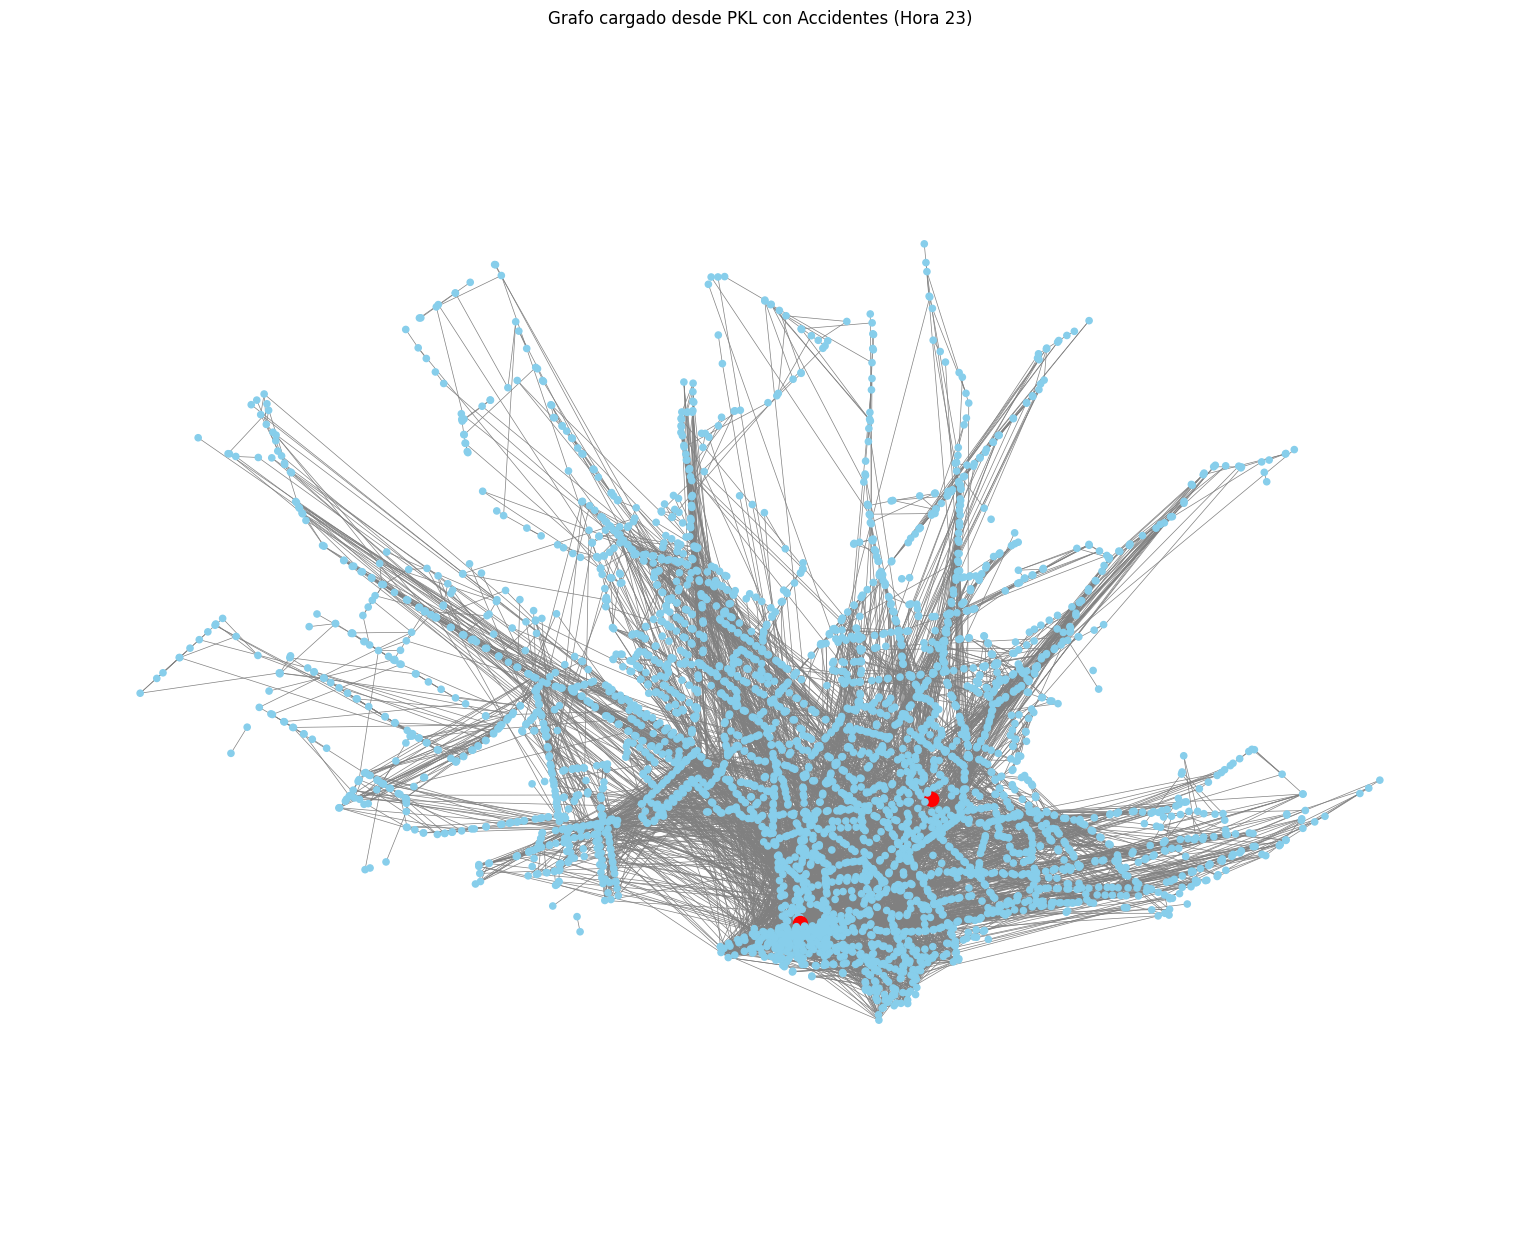

In [ ]:
graficar_grafo(loaded_graph, title="Grafo cargado desde PKL con Accidentes", hour=23) # Assuming hour 23 from the loaded file name

In [ ]:
weighted_edges_count = 0
for u, v, data in loaded_graph.edges(data=True):
    if 'weight' in data:
        weighted_edges_count += 1

print(f"Number of edges in graph G with a 'weight' attribute: {weighted_edges_count}")

Number of edges in graph G with a 'weight' attribute: 7318


In [ ]:
con_peso = sum(1 for u, v, d in loaded_graph.edges(data=True) if 'weight' in d)
print(f"\nAristas con peso real: {con_peso} de {G.number_of_edges()}")


Aristas con peso real: 7318 de 7318


In [ ]:
print("\n--- Searching for an edge with a significant observed difference (from theoretical) ---")

found_significant_difference_edge = False
for u_loaded, v_loaded, data_loaded in loaded_graph.edges(data=True):
    if 'weight' in data_loaded:
        loaded_difference_weight = data_loaded['weight'] # This is now the DIFFERENCE

        # Get the original theoretical weight from G for comparison display
        G_weight = None
        if G.has_edge(u_loaded, v_loaded) and 'weight' in G[u_loaded][v_loaded]:
            G_weight = G[u_loaded][v_loaded]['weight']
        elif G.has_edge(v_loaded, u_loaded) and 'weight' in G[v_loaded][u_loaded]:
            G_weight = G[v_loaded][u_loaded]['weight']

        # The actual difference is loaded_difference_weight. We check its absolute value.
        if abs(loaded_difference_weight) > 5.0: # Check if the absolute difference is greater than 5 minutes
            print(f"Significant Difference Edge Found: ({u_loaded}, {v_loaded})")
            print(f"  Observed Difference Weight: {loaded_difference_weight:.2f} min")
            if G_weight is not None:
                # Reconstruct implied observed_travel_time for display purposes
                observed_travel_time = G_weight + loaded_difference_weight
                print(f"  Theoretical Weight in G: {G_weight:.2f} min")
                print(f"  Implied Observed Travel Time: {observed_travel_time:.2f} min")
            else:
                print("  Theoretical Weight in G: Not found (or 0 implied for new edge)")
            print(f"  Absolute Value of Difference: {abs(loaded_difference_weight):.2f} min")
            found_significant_difference_edge = True
            break

if not found_significant_difference_edge:
    print("No edge found with an absolute difference greater than 5 minutes.")


--- Searching for an edge with a difference > 5 minutes ---
Significant Difference Edge Found: (4729, 4865)
  Weight in loaded_graph (difference): 64.45 min
  Weight in G (theoretical): 0.03 min
  Absolute Difference: 64.42 min


In [ ]:
count_significant_differences = 0

for u_loaded, v_loaded, data_loaded in loaded_graph.edges(data=True):
    if 'weight' in data_loaded:
        loaded_difference_weight = data_loaded['weight'] # This is the DIFFERENCE

        # We are simply counting edges where the difference itself is not zero
        if abs(loaded_difference_weight) > 0:
            count_significant_differences += 1

print(f"Number of edges with an observed weight difference (from theoretical) greater than 0: {count_significant_differences}")

Number of edges with an observed weight difference (from theoretical) greater than 0: 3458
